In [1]:
'''
KerasGA https://pypi.org/project/KerasGA/   https://pygad.readthedocs.io/en/latest/kerasga.html
Fuente: https://anderfernandez.com/blog/algoritmo-genetico-en-python/#C%C3%B3mo-usar-un-algoritmo-gen%C3%A9tico-en-Python-con-PyGAD
AG en 5 minutos: https://www.youtube.com/watch?v=RBrXGyo0kIw&list=RDLV_ZxrvAi0Mk0&index=7
Colab: http://fcaglp.unlp.edu.ar/~gbaume/grupo/Publicaciones/Apuntes/GoogleColab.pdf
'''
!pip install pygad
import warnings
import seaborn as sns
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.losses import BinaryCrossentropy

from pygad import kerasga, GA

warnings.simplefilter('ignore')



ModuleNotFoundError: No module named 'keras'

In [ ]:
# CARGAMOS EL DATASET DE CANCER DE MAMA DESDE SKLEARN

cancer = load_breast_cancer(as_frame = True)
data = cancer['data']
target = cancer['target']

print(f'Shape data: {data.shape}')
print(f'Shape target: {target.shape}')
cancer

Shape data: (569, 30)
Shape target: (569,)


{'data':      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  me

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
target.unique()

array([0, 1])

<Axes: xlabel='target'>

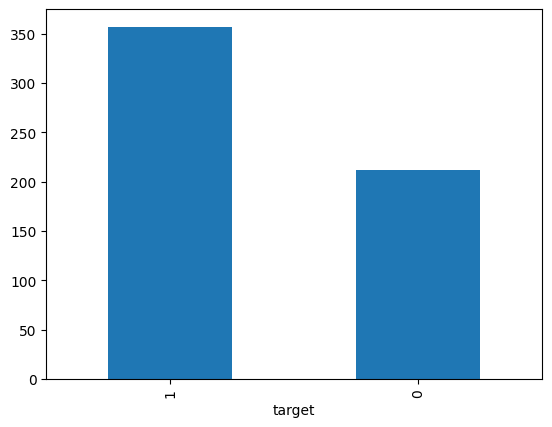

In [ ]:
bar=target.value_counts()
bar.plot(kind='bar')


In [ ]:
data


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# SEPARAR TRAIN Y TEST 80/20
x_train, x_test, y_train, y_test = train_test_split(data, target, stratify=target, random_state=16)
y_test

,target
439,1
352,0
455,1
540,1
136,1
...,...
289,1
358,1
236,0
341,1


In [ ]:
x_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
416,9.405,21.70,59.60,271.2,0.10440,0.06159,0.02047,0.012570,0.2025,0.06601,...,10.850,31.24,68.73,359.4,0.1526,0.11930,0.06141,0.03770,0.2872,0.08304
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.1324,0.11480,0.08867,0.06227,0.2450,0.07773
467,9.668,18.10,61.06,286.3,0.08311,0.05428,0.01479,0.005769,0.1680,0.06412,...,11.150,24.62,71.11,380.2,0.1388,0.12550,0.06409,0.02500,0.3057,0.07875
430,14.900,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.097110,0.2041,0.06898,...,16.350,27.57,125.40,832.7,0.1419,0.70900,0.90190,0.24750,0.2866,0.11550
69,12.780,16.49,81.37,502.5,0.09831,0.05234,0.03653,0.028640,0.1590,0.05653,...,13.460,19.76,85.67,554.9,0.1296,0.07061,0.10390,0.05882,0.2383,0.06410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,20.440,21.78,133.80,1293.0,0.09150,0.11310,0.09799,0.077850,0.1618,0.05557,...,24.310,26.37,161.20,1780.0,0.1327,0.23760,0.27020,0.17650,0.2609,0.06735
409,12.270,17.92,78.41,466.1,0.08685,0.06526,0.03211,0.026530,0.1966,0.05597,...,14.100,28.88,89.00,610.2,0.1240,0.17950,0.13770,0.09532,0.3455,0.06896
488,11.680,16.17,75.49,420.5,0.11280,0.09263,0.04279,0.031320,0.1853,0.06401,...,13.320,21.59,86.57,549.8,0.1526,0.14770,0.14900,0.09815,0.2804,0.08024
432,20.180,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.030,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075


In [ ]:
y_test

,target
439,1
352,0
455,1
540,1
136,1
...,...
289,1
358,1
236,0
341,1


In [ ]:
# Escalamos los datos de entrenamiento usando StandardScaler
# Este proceso transforma las variables para que tengan media = 0 y desviación estándar = 1
scaler = StandardScaler()

# Ajusta el scaler al conjunto de entrenamiento y aplica la transformación
# fit_transform() primero calcula la media y desviación del entrenamiento, luego escala los datos
x_train_sc = scaler.fit_transform(x_train)

# Mostramos los datos ya escalados (valores normalizados)
x_train_sc

array([[-1.35644161,  0.58702395, -1.34690674, ..., -1.16555751,
        -0.08709388, -0.04590727],
       [-1.32795945, -1.55398142, -1.31607745, ..., -0.7936818 ,
        -0.76946655, -0.33935417],
       [-1.28077687, -0.24533235, -1.28608139, ..., -1.35777654,
         0.21205054, -0.28298584],
       ...,
       [-0.70192724, -0.69156781, -0.6849102 , ..., -0.2506252 ,
        -0.19704966, -0.20064386],
       [ 1.74351107,  0.08761017,  1.74435464, ...,  1.55275255,
         0.17162562, -0.1724597 ],
       [-1.5051818 , -1.04531924, -1.38065232, ..., -1.01178229,
        -1.08639793,  1.3555642 ]])

In [ ]:
x_test_sc=scaler.transform(x_test)
x_test_sc

array([[-0.02871246, -0.80948495, -0.09748722, ..., -0.49263955,
        -1.27720355, -0.92680061],
       [ 3.34023843, -0.3933068 ,  3.4274673 , ...,  2.43514385,
         1.23560954,  0.23648702],
       [-0.21283958,  2.67253889, -0.23288613, ..., -0.56120272,
        -1.18018374, -0.39351198],
       ...,
       [ 2.6152379 ,  1.80550108,  2.56508037, ...,  2.18843753,
         0.28643239,  0.16022399],
       [-1.29861419, -0.53665706, -1.26191789, ..., -0.50716949,
         0.09077577,  0.79464403],
       [-1.04716559, -0.96670781, -1.01819984, ..., -0.32705875,
         0.15222165,  0.69572314]])

In [ ]:
x_train_sc.shape

(426, 30)

In [ ]:
type(x_train_sc.shape[1])

int

In [ ]:
# Creamos una red neuronal completamente conectada (Fully Connected / Feedforward)
# Objetivo: clasificar datos binarios (salida 0 o 1)

model = Sequential()  # inicializamos el modelo secuencial

# Capa de entrada: define el tamaño del input según la cantidad de variables de x_train_sc
model.add(Input(shape=(x_train_sc.shape[1],)))

# Primera capa oculta con 16 neuronas y función de activación ReLU (rectificada)
model.add(Dense(16, activation='relu'))

# Segunda capa oculta con 8 neuronas y activación ReLU
model.add(Dense(8, activation='relu'))

# Capa de salida con 1 neurona y activación sigmoide
# (ideal para problemas de clasificación binaria)
model.add(Dense(1, activation='sigmoid'))

# Muestra el resumen del modelo: capas, número de parámetros y conexiones
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  acá aparece la magia: integración entre red y AG!!! by Keras :)
# https://pygad.readthedocs.io/en/latest/kerasga.html#examples

keras_ga = kerasga.KerasGA(model = model, num_solutions = 15)

In [ ]:
#   para optimizar los parámetros, creamos el AG: primero definir FITNESS

def fitness_func(ga_instance, solution, solution_idx ):
  global model

  # Get the weights from the model
  weights = kerasga.model_weights_as_matrix(model= model,
                                            weights_vector= solution)

  # Set the weights
  model.set_weights(weights = weights)

  # Make the prediction
  prediction = model.predict(x_train_sc, verbose=0)

  # Calculate fitness
  entropy = BinaryCrossentropy()(y_train, prediction)
  fitness = 1/(entropy.numpy() + 0.0001)

  return fitness


In [ ]:
#    agregamos un 'callback' para observar cómo va aprendiendo la red neuronal

fitness_evol = []

def callback_generation(ga_instance):

  global fitness_evol
  fitness_evol.append(ga_instance.best_solution()[1])
  generation = ga_instance.generations_completed

  if generation % 2 == 0:
    print(f"Generation {generation}. Fitness: {ga_instance.best_solution()[1]}")


In [ ]:
#  ya podemos entrenar la red usando las soluciones del AG

num_generations = 50
num_parents_mating = 10
initial_population = keras_ga.population_weights

ga_optimizer = GA(num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    initial_population=initial_population,
    #mutation_type="random",
    #mutation_probability=0.9,
    fitness_func=fitness_func,
    on_generation=callback_generation)

ga_optimizer.run()

Generation 2. Fitness: 2.5588065247841603
Generation 4. Fitness: 2.7951578731770694
Generation 6. Fitness: 2.7951578731770694
Generation 8. Fitness: 2.7951578731770694
Generation 10. Fitness: 3.5439481244345816
Generation 12. Fitness: 3.5439481244345816
Generation 14. Fitness: 3.5439481244345816
Generation 16. Fitness: 3.5439481244345816
Generation 18. Fitness: 4.273177540154952
Generation 20. Fitness: 4.273177540154952
Generation 22. Fitness: 4.273177540154952
Generation 24. Fitness: 4.273177540154952
Generation 26. Fitness: 4.273177540154952
Generation 28. Fitness: 5.737685987557546
Generation 30. Fitness: 5.737685987557546
Generation 32. Fitness: 5.737685987557546
Generation 34. Fitness: 6.992429667569
Generation 36. Fitness: 6.992429667569
Generation 38. Fitness: 8.754565942690826
Generation 40. Fitness: 9.769610336458598
Generation 42. Fitness: 9.769610336458598
Generation 44. Fitness: 9.769610336458598
Generation 46. Fitness: 12.31379391154102
Generation 48. Fitness: 12.313793911

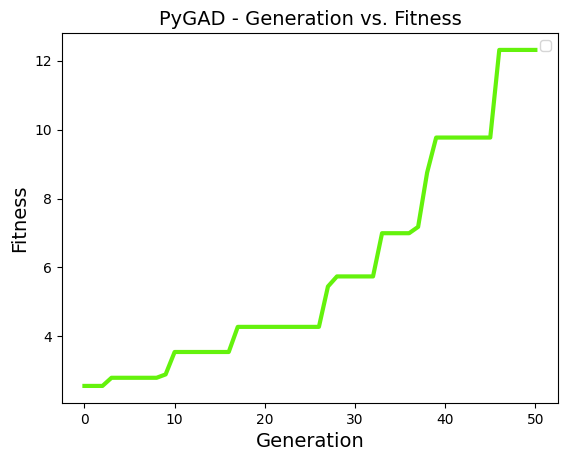

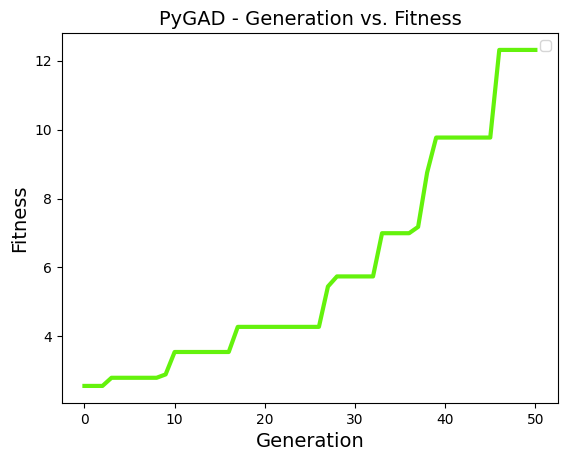

In [ ]:
ga_optimizer.plot_fitness()

In [ ]:
solution, solution_fitness, solution_idx = ga_optimizer.best_solution()


In [ ]:
solution_fitness

12.31379391154102

In [ ]:
solution_idx

0

In [ ]:
solution

array([-4.92606091e-01, -1.77092389e+00,  1.73844556e+00, -6.37947605e-01,
       -1.02895917e-01,  2.13118681e+00, -7.11822446e-01,  6.87864218e-01,
        3.26231382e-01,  1.88162961e+00, -8.30626227e-01,  2.33671288e+00,
        3.06432796e+00, -1.35741456e+00, -6.86971501e-01, -7.59596999e-01,
       -1.50383361e+00, -8.99135238e-01,  4.91795440e-02,  8.78410410e-01,
        2.91456294e-01,  1.24716152e+00,  1.69176075e+00,  8.97912480e-01,
       -9.61127546e-02, -1.73289175e+00,  4.53946096e-01,  4.20478671e-01,
       -9.33364842e-02, -1.68470036e+00,  2.85180905e-01,  4.11948897e-01,
       -6.73969655e-02,  2.51100211e-01, -8.30744669e-01,  1.19127276e-02,
       -1.71866856e+00, -8.20562708e-01,  1.23973693e+00,  6.20035109e-01,
        6.21028011e-01, -1.20794411e+00, -3.26030841e-01,  2.38076328e+00,
       -1.15532524e+00,  1.14404388e+00,  1.80150352e+00, -4.46579344e-01,
       -1.48279309e+00,  1.28989712e+00,  5.61100107e-01, -6.77946323e-01,
        2.96233760e+00, -

<Axes: >

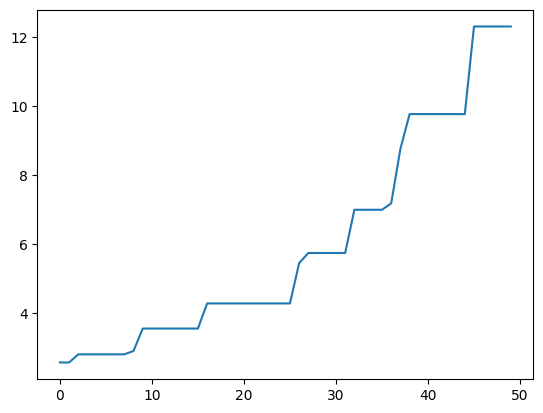

In [ ]:
#   para ver cómo fue aprendiendo el modelo, graficamos su evolución
import seaborn as sns
sns.lineplot(x = range(len(fitness_evol)),
             y = fitness_evol)


In [ ]:
#   ahora pedimos a la RN q prediga sobre datos nuevos (usamos el cjto de test) y vemos cómo le va
# hay dos maneras de obtener las predicciones


pred = kerasga.predict(model=model, solution=solution, data=x_test_sc)
pred


array([[1.00000000e+00],
       [5.18057906e-22],
       [4.02579814e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.27452087e-01],
       [4.05064434e-01],
       [9.99763310e-01],
       [3.90620083e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.97056723e-01],
       [1.00000000e+00],
       [9.98590887e-01],
       [3.16100603e-08],
       [1.01417559e-03],
       [5.20791952e-03],
       [1.00000000e+00],
       [2.10567996e-05],
       [1.00000000e+00],
       [4.86178411e-04],
       [4.29741413e-05],
       [5.92395510e-09],
       [9.99958515e-01],
       [1.00000000e+00],
       [8.03442257e-10],
       [9.99998987e-01],
       [9.99640763e-01],
       [1.65602717e-06],
       [3.66086283e-07],
       [7.48929736e-08],
       [9.99617040e-01],
       [1.00000000e+00],
       [5.47015179e-06],
       [1.00000000e+00],
       [5.18843532e-01],
       [1.77450329e-01],
       [1.00000000e+00],
       [9.99999821e-01],


In [ ]:
pred2 = model.predict(x_test_sc)
pred2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[1.00000000e+00],
       [8.82714248e-34],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.99999881e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.99998748e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [7.68491659e-10],
       [1.00280706e-09],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.03905435e-11],
       [1.00000000e+00],
       [3.13259603e-04],
       [4.35480056e-03],
       [1.95576281e-11],
       [9.99999344e-01],
       [1.00000000e+00],
       [4.09216395e-20],
       [8.56703818e-01],
       [1.00000000e+00],
       [3.61132523e-04],
       [9.61349784e-15],
       [1.41148348e-05],
       [1.00000000e+00],
       [1.00000000e+00],
       [6.56035155e-08],
       [1.00000000e+00],
       [9.97295499e-01],
       [5.22699833e-01],
       [1.00000000e+00],
       [9.95070219e-01],


In [ ]:
np.array_equal(pred, pred2)

False

In [ ]:
print(type(y_test))
print(type(pred))


<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>


In [ ]:
import numpy as np
classes=np.argmax(pred,axis=0)

In [ ]:
type(classes)

numpy.ndarray

In [ ]:
classes

array([0])

In [ ]:
pre=np.round(pred, 0)
pre

array([[1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],

In [ ]:
import pandas as pd
pre_pd=pd.DataFrame(pre)
pre_pd

,0
0,1.0
1,0.0
2,0.0
3,1.0
4,1.0
...,...
138,1.0
139,1.0
140,0.0
141,1.0


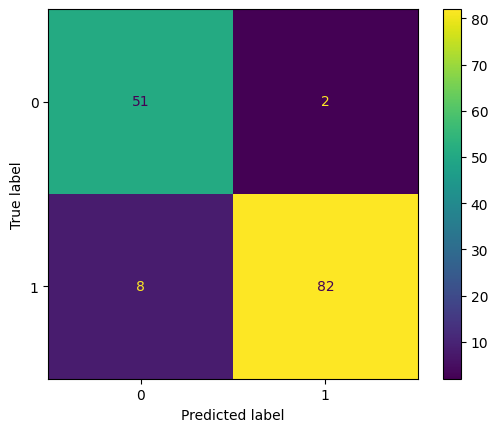

In [ ]:
cm = confusion_matrix(y_test, pre_pd)
ConfusionMatrixDisplay(cm).plot()
